# **1) RUN THE FOLLOWING CODE BLOCKS AS IS**


In [11]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from mamba_ssm import Mamba2 as Mamba
from filterpy.kalman import KalmanFilter

# Set random seeds for reproducibility
seed = 42
global rng 
rng = np.random.default_rng(seed)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [53]:
# 2. System Dynamics Model (LTI Filtering System)

class FilterSim:
    """
    LTI system simulator with configurable dynamics.

    Parameters:
    - nx: state dimension
    - ny: output dimension
    - sigma_w: process noise std
    - sigma_v: measurement noise std
    - A: system matrix (if None, will be randomly generated)
    - C: output matrix (if None, will be randomly generated)
    """

    def __init__(self, nx=10, ny=5, sigma_w=0.1, sigma_v=0.1, A=None, B=None, C=None,
                 eig_low=0.5, eig_high=0.8, input_lower=0.0, input_upper=1.0):
        self.nx = nx
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.input_lower = input_lower
        self.input_upper = input_upper

        # Generate random stable system matrix if not provided
        if A is None:
            self.A = self._generate_random_stable_matrix(nx, eig_low=eig_low, eig_high=eig_high)
        else:
            self.A = A

        # Generate random controllable matrix if not provided
        if B is None:
            self.B = self._generate_controllable_B(nx, self.A)
        else:
            self.B = B

        # Generate random observable matrix if not provided
        if C is None:
            self.C = self._generate_observable_C(nx, ny, self.A)
        else:
            self.C = C

    @staticmethod
    def _generate_random_stable_matrix(n, eig_low=0.5, eig_high=0.8, max_tries=1000):
        """Generate a random stable matrix with eigenvalues in [eig_low, eig_high]"""
        for _ in range(max_tries):
            # Generate random eigenvalues in the stable region
            eigs = rng.uniform(eig_low, eig_high, size=n)
            Lambda = np.diag(eigs)

            # Generate random invertible matrix
            P = rng.standard_normal(size=(n,n))
            if np.linalg.matrix_rank(P) == n:
                A = P @ Lambda @ np.linalg.inv(P)
                # Check spectral radius for stability
                if np.max(np.abs(np.linalg.eigvals(A))) < 0.95:
                    return A

        # Fallback: diagonal matrix
        return np.diag(rng.uniform(eig_low, eig_high, size=n))
    
    @staticmethod
    def _generate_controllable_B(nx, A):
        """Generate a random B matrix that ensures controllability"""
        for _ in range(100):
            B = rng.standard_normal(size=(nx,nx))
            # Check controllability matrix rank
            CO = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(nx)], axis=1)
            if np.linalg.matrix_rank(CO) == nx:
                return B.astype(np.float32)
        raise RuntimeError("Could not generate controllable B matrix")

    @staticmethod
    def _generate_observable_C(nx, ny, A):
        """Generate a random C matrix that ensures observability"""
        for _ in range(100):
            C = rng.standard_normal(size=(ny, nx))
            # Check observability matrix rank
            O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                              for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(O) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate observable C matrix")

    def simulate(self, traj_len, x0=None, input_lower=None, input_upper=None):
        """
        Simulate a trajectory.

        Args:
            traj_len: number of time steps
            x0: initial state (if None, random)
            input_lower: lower bound for control inputs (if None, uses self.input_lower)
            input_upper: upper bound for control inputs (if None, uses self.input_upper)

        Returns:
            states: (traj_len+1, nx) array of states
            outputs: (traj_len+1, ny) array of noisy observations
            inputs: (traj_len, nx) array of control inputs
        """
        nx, ny = self.nx, self.ny

        # Use instance defaults if not provided
        if input_lower is None:
            input_lower = self.input_lower
        if input_upper is None:
            input_upper = self.input_upper

        # Initialize
        x = rng.standard_normal(size=nx) if x0 is None else x0
        states = [x]
        outputs = [self.C @ x + rng.standard_normal(ny) * self.sigma_v]
        inputs = []

        for _ in range(traj_len):
            # Generate random control input (uniform in [input_lower, input_upper])
            # u = rng.uniform(input_lower, input_upper, size=nx)
            S = np.diag(np.abs(rng.normal(0, input_upper, size=CONFIG['nx'])))
            P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
            while np.linalg.matrix_rank(P) != CONFIG['nx']:
                P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
            S = P @ S @ P.T
            u = rng.multivariate_normal(input_lower*np.ones(nx), S)

            u = rng.multivariate_normal(input_lower*np.ones(nx), np.diag(input_upper*np.ones(nx)))
            inputs.append(u)

            # State transition with process noise
            x = self.A @ x + self.B @ u + rng.standard_normal(size=nx) * self.sigma_w
            states.append(x)

            # Observation with measurement noise
            y = self.C @ x + rng.standard_normal(size=ny) * self.sigma_v
            outputs.append(y)

        return (np.array(states, dtype=np.float32),
                np.array(outputs, dtype=np.float32),
                np.array(inputs, dtype=np.float32))

def apply_kalman_filter(fsim, obs, inputs=None, x0=None, P0=None, sigma_w=None, sigma_v=None):
    """
    Apply Kalman filter to a trajectory's observations with control inputs.

    Args:
        fsim: FilterSim instance with A and C matrices
        obs: (traj_len+1, ny) array of noisy observations
        inputs: (traj_len, nx) array of control inputs (if None, assumes no control)
        x0: initial state estimate (if None, uses zeros)
        P0: initial covariance (if None, uses identity)
        sigma_w: process noise (if None, uses fsim.sigma_w)
        sigma_v: measurement noise (if None, uses fsim.sigma_v)

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    ny, nx = fsim.C.shape

    sigma_w = fsim.sigma_w if sigma_w is None else sigma_w
    sigma_v = fsim.sigma_v if sigma_v is None else sigma_v

    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    kf.Q = np.eye(nx) * sigma_w ** 2
    kf.R = np.eye(ny) * sigma_v ** 2
    kf.P = np.eye(nx) if P0 is None else P0
    kf.x = np.zeros(nx) if x0 is None else x0
    kf.F = fsim.A
    kf.H = fsim.C

    # Control matrix B is identity for this system (x_{t+1} = A @ x_t + u_t + w_t)
    kf.B = fsim.B

    # Store predictions
    kf_states = []

    # Process first observation y_0 to estimate x_0
    if len(obs) > 0:
        kf.update(obs[0])
        kf_states.append(kf.x.copy())


    # Process remaining observations: predict with u_i, update with y_{i+1}
    for i in range(len(inputs)):
        # Standard Kalman filter loop: predict next state, then update with observation
        if inputs is not None and i < len(inputs):
            kf.predict(u=inputs[i])
        else:
            kf.predict()
        kf.update(obs[i+1])
        kf_states.append(kf.x.copy())

    return np.array(kf_states, dtype=np.float32)


def apply_kalman_filter_from_traj(traj):
    """
    Apply Kalman filter to a trajectory dictionary.

    Args:
        traj: trajectory dictionary with 'obs', 'inputs', 'A', 'C' (and optionally 'sigma_w', 'sigma_v')

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    # Create a FilterSim instance with the trajectory's parameters
    nx = traj['A'].shape[0]
    ny = traj['C'].shape[0]

    # Get noise parameters from trajectory or use defaults
    sigma_w = traj.get('sigma_w', 0.1)  # Default to 0.1 if not present
    sigma_v = traj.get('sigma_v', 0.1)  # Default to 0.1 if not present

    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v)
    fsim.A = traj['A']
    fsim.B = traj['B']
    fsim.C = traj['C']

    return apply_kalman_filter(fsim, traj['obs'], traj['inputs'])


def generate_trajectory(nx=10, ny=5, traj_len=50, sigma_w=0.1, sigma_v=0.1,
                         input_lower=0.0, input_upper=1.0, A=None, B=None, C=None,
                         eig_low=0.5, eig_high=0.8):
    """
    Generate a single trajectory with configurable parameters.

    Returns:
        dict with 'states', 'obs', 'inputs', 'A', 'C', 'sigma_w', 'sigma_v'
    """
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v, A=A, B=B, C=C,
                     eig_low=eig_low, eig_high=eig_high,
                     input_lower=input_lower, input_upper=input_upper)
    states, obs, inputs = fsim.simulate(traj_len, input_lower=input_lower, input_upper=input_upper)

    return {
        'states': states,
        'obs': obs,
        'inputs': inputs,
        'A': fsim.A,
        'B': fsim.B,
        'C': fsim.C,
        'sigma_w': sigma_w,
        'sigma_v': sigma_v
    }

In [13]:
# 3. Dataset Preparation

class TrajectoryDataset(Dataset):
    """
    Dataset that provides trajectories for training.
    Each sample is a trajectory with states, observations, and inputs.
    """

    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory()
        """
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        """
        Returns a sample dict with:
        - xs: input features (concatenated observation and input)
        - ys: target (state)
        """
        traj = self.trajectories[idx % len(self.trajectories)]

        states = traj['states']  # (traj_len+1, nx)
        obs = traj['obs']  # (traj_len+1, ny)
        inputs = traj['inputs']  # (traj_len, nx)

        # Input: [output_t, input_{t-1}], Target: state_t
        # Use noisy observations as input (filtering: estimate state from observation and input)
        xs = np.concatenate([obs[1:], inputs], axis=-1)  # (traj_len, ny+nx)
        ys = states[1:]  # (traj_len, nx)

        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float()
        }


def create_datasets(num_train=1000, num_val=200, traj_len=50,
                    nx=10, ny=5, sigma_w=0.1, sigma_v=0.1,
                    input_lower=0.0, input_upper=1.0,
                    eig_low=0.5, eig_high=0, A=None, B=None, C=None):
    """
    Create training and validation datasets.

    Returns:
        train_dataset, val_dataset
    """
    print("Generating training trajectories...")
    train_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_train))
    ]

    print("Generating validation trajectories...")
    val_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_val))
    ]

    return TrajectoryDataset(train_traj), TrajectoryDataset(val_traj)

In [14]:
# 4. Mamba SSM Model

class MambaFilter(LightningModule):
    """
    Mamba SSM model for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach but using Mamba instead of Transformer.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 d_model=256, n_layers=4, d_state=16, d_conv=4, expand=2,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            d_model: model dimension
            n_layers: number of Mamba layers
            d_state: state dimension for Mamba
            d_conv: convolution dimension for Mamba
            expand: expansion factor for Mamba
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.d_model = d_model
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input projection to model dimension
        self.input_proj = nn.Linear(input_dim, d_model)

        # Layer norm for input
        self.input_ln = nn.LayerNorm(d_model)

        # Mamba SSM layers
        self.mamba_layers = nn.ModuleList([
            Mamba(
                d_model=d_model,
                d_state=d_state,
                d_conv=d_conv,
                expand=expand
            ) for _ in range(n_layers)
        ])

        # Layer norm between layers
        self.layer_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])

        # Output projection
        self.output_proj = nn.Linear(d_model, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

        # Initialize weights properly
        self.apply(self._init_weights)
        # Force all submodules to train mode
        self.train()

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input projection
        x = self.input_proj(xs)  # (batch_size, seq_len, d_model)
        x = self.input_ln(x)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Apply Mamba layers with layer norm
        for i, layer in enumerate(self.mamba_layers):
            x = layer(x)
            x = self.layer_norms[i](x)

        # Output projection
        preds = self.output_proj(x)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }

In [15]:
# 5. Training Setup

class SequenceDataModule(pl.LightningDataModule):
    """Lightning data module for trajectory data."""

    def __init__(self, train_dataset, val_dataset=None, batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            drop_last=False
        )

    def val_dataloader(self):
        if self.val_dataset is not None:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None

    def test_dataloader(self):
        if hasattr(self, 'test_dataset') and self.test_dataset is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None

In [16]:
# 6. Save and Load Model

def save_model(model, path='mamba_meta_output_predictor.pth', config=None):
    """Save the trained model."""
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config
    }, path)
    print(f"Model saved to {path}")


def load_model(path='mamba_meta_output_predictor.pth', config=None):
    """Load a saved model."""
    checkpoint = torch.load(path, map_location=device)

    if config is None:
        config = checkpoint.get('config', {})

    input_dim = config.get('ny', 5) + config.get('nx', 10)
    output_dim = config.get('nx', 10)

    model = MambaFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=config.get('n_positions', 50),
        d_model=config.get('d_model', 256),
        n_layers=config.get('n_layers', 2),
        d_state=config.get('d_state', 32),
        d_conv=config.get('d_conv', 4),
        expand=config.get('expand', 2),
        learning_rate=config.get('learning_rate', 3e-5),
        weight_decay=config.get('weight_decay', 1e-4),
        gradient_clip=config.get('gradient_clip', 1.0)
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"Model loaded from {path}")
    return model, config

# **2) START EDITING PARAMETERS HERE**


In [47]:
# Configuration parameters
CONFIG = {
    # System dimensions
    'nx': 10,           # State dimension
    'ny': 5,            # Output dimension

    # Trajectory parameters
    'traj_len': 50,     # Length of each trajectory
    'num_train': 20000,  # Number of training trajectories
    'num_val': 5000,     # Number of validation trajectories
    'num_test': 100,    # Number of test trajectories

    # Noise parameters (training)
    'sigma_w_train': 0.01,  # Process noise
    'sigma_v_train': 0.01,  # Measurement noise
    'input_lower_train': 0.0,  # Input lower bound (mean if Gaussian)
    'input_upper_train': 0.1,  # Input upper bound (variance if Gaussian)
    'eig_low_train': np.nextafter(0, 1),    # Eigenvalue lower bound
    'eig_high_train': 0.9,   # Eigenvalue upper bound

    # Noise parameters (testing) - can be different!
    'sigma_w_test': 0.01,    # Higher process noise for testing
    'sigma_v_test': 0.01,    # Higher measurement noise for testing
    'input_lower_test': 0.5,  # Input lower bound for testing (mean if Gaussian)
    'input_upper_test': 0.1,  # Input upper bound for testing (variance if Gaussian)
    'eig_low_test': np.nextafter(0, 1),      # Eigenvalue lower bound for testing
    'eig_high_test': 0.9,    # Eigenvalue upper bound for testing

    # Model parameters
    'n_positions': 50,   # Maximum sequence length
    'd_model': 128,        # Model dimension
    'n_layers': 6,         # Number of Mamba layers
    'd_state': 16,          # State dimension for Mamba
    'd_conv': 4,           # Convolution dimension for Mamba
    'expand': 2,            # Expansion factor for Mamba

    # Training parameters
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,

    # Output paths
    'save_model': None,
    'save_plot': 'results_mamba.png',
}

print("="*60)
print("SSM FILTER (MAMBA)")
print("="*60)
print(f"Configuration: {CONFIG}")
print()

SSM FILTER (MAMBA)
Configuration: {'nx': 10, 'ny': 5, 'traj_len': 50, 'num_train': 20000, 'num_val': 5000, 'num_test': 100, 'sigma_w_train': 0.01, 'sigma_v_train': 0.01, 'input_lower_train': 0.0, 'input_upper_train': 0.1, 'eig_low_train': np.float64(5e-324), 'eig_high_train': 0.9, 'sigma_w_test': 0.01, 'sigma_v_test': 0.01, 'input_lower_test': 0.5, 'input_upper_test': 0.1, 'eig_low_test': np.float64(5e-324), 'eig_high_test': 0.9, 'n_positions': 50, 'd_model': 128, 'n_layers': 6, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'batch_size': 32, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'gradient_clip': 1.0, 'save_model': None, 'save_plot': 'results_mamba.png'}



In [50]:
# Step 1: Create datasets
print("\n[1/4] Creating datasets...")
A = np.diag(rng.uniform(np.nextafter(0,1), 0.95, size=CONFIG['nx']))
P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
while np.linalg.matrix_rank(P) != CONFIG['nx']:
    P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
A = P @ A @ np.linalg.solve(P, np.eye(CONFIG['nx']))

B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
for _ in range(100):
    B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
    # Check controllability matrix rank
    CO = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(CONFIG['nx'])], axis=1)
    if np.linalg.matrix_rank(CO) == CONFIG['nx']:
        break

C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
for _ in range(100):
    C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
    # Check observability matrix rank
    O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                        for i in range(CONFIG['nx'])], axis=0)
    if np.linalg.matrix_rank(O) == CONFIG['nx']:
        break

train_dataset, val_dataset = create_datasets(
    num_train=CONFIG['num_train'],
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    input_lower=CONFIG['input_lower_train'],
    input_upper=CONFIG['input_upper_train'],
    eig_low=CONFIG['eig_low_train'],
    eig_high=CONFIG['eig_high_train'],
    A=A,
    B=B,
    C=C
)

# Create data loaders
train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG['batch_size'],
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=CONFIG['batch_size'],
                        shuffle=False)

print(f"Train dataset: {len(train_dataset)} trajectories")
print(f"Val dataset: {len(val_dataset)} trajectories")

# Step 2: Create model
print("\n[2/4] Creating model...")
input_dim = CONFIG['ny'] + CONFIG['nx']  # observation + input dimensions
output_dim = CONFIG['nx']  # predict state

model = MambaFilter(
    input_dim=input_dim,
    output_dim=output_dim,
    n_positions=CONFIG['n_positions'],
    d_model=CONFIG['d_model'],
    n_layers=CONFIG['n_layers'],
    d_state=CONFIG['d_state'],
    d_conv=CONFIG['d_conv'],
    expand=CONFIG['expand'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    gradient_clip=CONFIG['gradient_clip']
)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


[1/4] Creating datasets...
Generating training trajectories...


100%|██████████| 20000/20000 [01:13<00:00, 271.28it/s]


Generating validation trajectories...


100%|██████████| 5000/5000 [00:18<00:00, 274.00it/s]

Train dataset: 20000 trajectories
Val dataset: 5000 trajectories

[2/4] Creating model...
Model: MambaFilter
Parameters: 632,850


In [51]:
# Step 3: Train the model with PyTorch Lightning
print("\n[3/4] Training model with PyTorch Lightning...")

# Create data module
datamodule = SequenceDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    num_workers=4
)

# Create trainer
trainer = pl.Trainer(
    max_epochs=CONFIG['num_epochs'],
    devices="auto",
    accelerator="auto",
    gradient_clip_val=CONFIG['gradient_clip'],
    log_every_n_steps=10,
    enable_progress_bar=True,
    default_root_dir=".",
)

# Train
trainer.fit(model, datamodule=datamodule)

# Get training history from Lightning logger
# Access the logged metrics
history = {
    'train_loss': [],
    'val_loss': []
}
if hasattr(trainer, 'logger') and trainer.logger is not None:
    # Try to extract metrics from logger
    pass  # Metrics are logged automatically by Lightning
print(f"Training complete. Best val loss: {trainer.callback_metrics.get('val_loss', float('inf')):.6f}")

# Save the trained model
trained_model = model

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'clip_value'}

  | Name         | Type       | Params | Mode 
----------------------------------------------------
0 | input_proj   | Linear     | 2.0 K  | train
1 | input_ln     | LayerNorm  | 256    | train
2 | mamba_layers | ModuleList | 627 K  | train
3 | layer_norms  | ModuleList | 1.5 K  | train
4 | output_proj  | Linear     | 1.3 K  | train
5 | criterion    | MSELoss    | 0      | train
----------------------------------------------------
632 K     Trainable param


[3/4] Training model with PyTorch Lightning...
Epoch 49: 100%|██████████| 625/625 [00:18<00:00, 34.71it/s, v_num=105, train_loss_step=177.0, val_loss=72.00, train_loss_epoch=93.10]      

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 625/625 [00:18<00:00, 34.54it/s, v_num=105, train_loss_step=177.0, val_loss=72.00, train_loss_epoch=93.10]
Training complete. Best val loss: 71.956566



Generating 10000 test trajectories for visualization...


100%|██████████| 10000/10000 [00:37<00:00, 263.24it/s]



Computing per-timestep summed L2 norm across all 10000 trajectories...


100%|██████████| 10000/10000 [01:08<00:00, 146.69it/s]



Average Summed L2 Error (Mamba) across ALL 10000 trajectories: 13759.722
Average Summed L2 Error (Kalman Filter) across ALL 10000 trajectories: 1.610


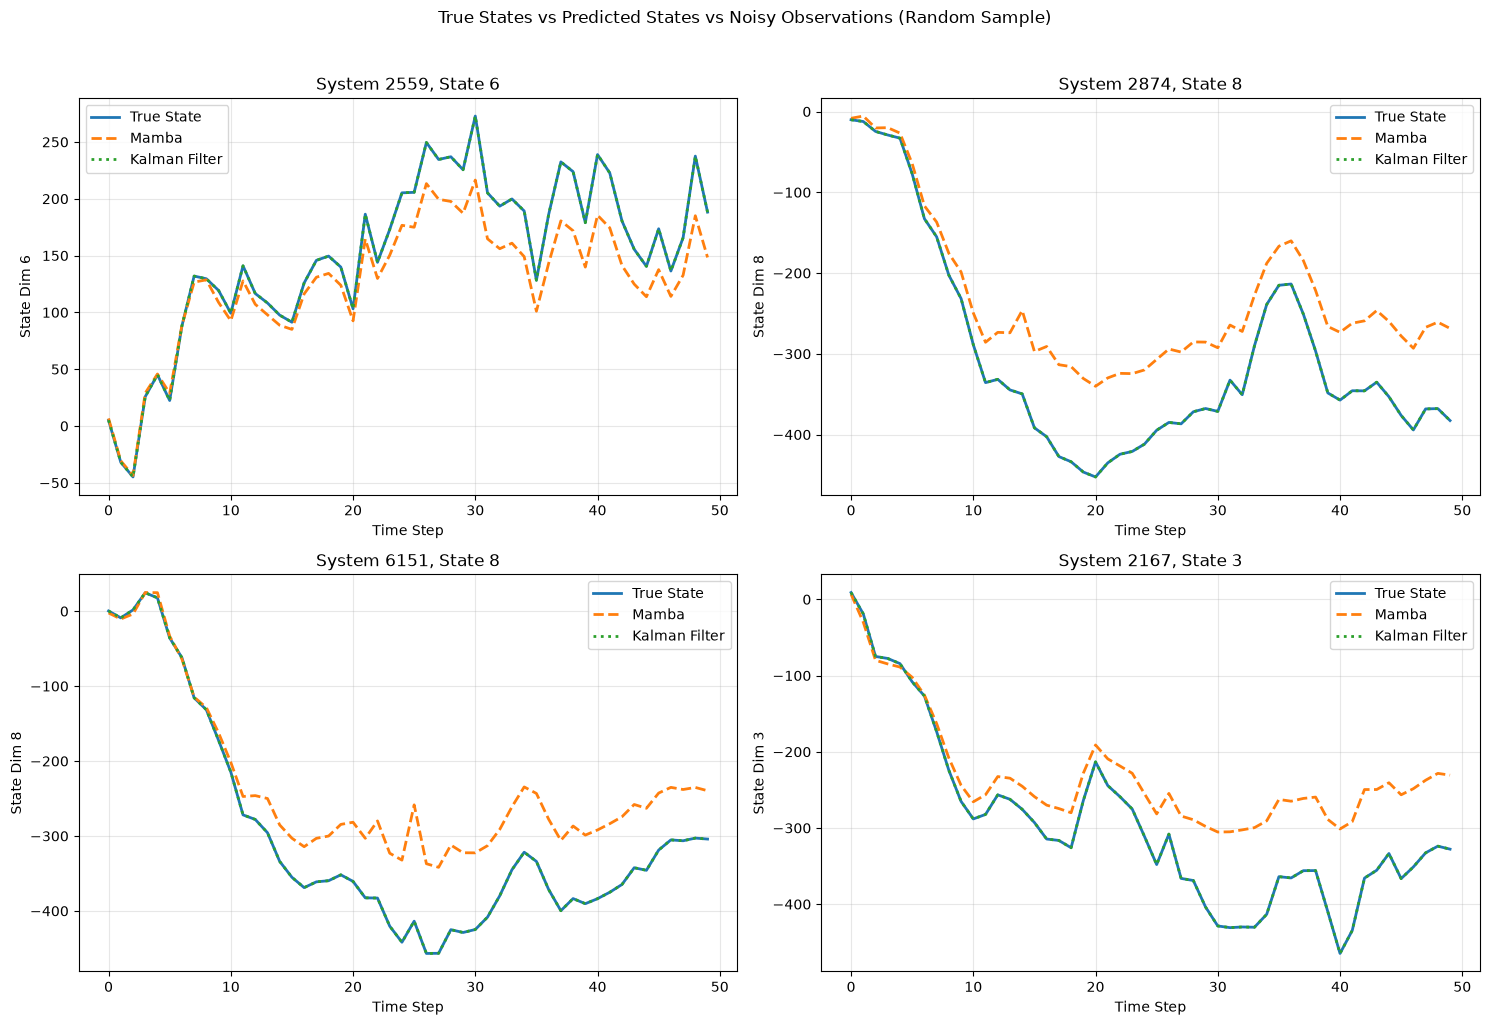

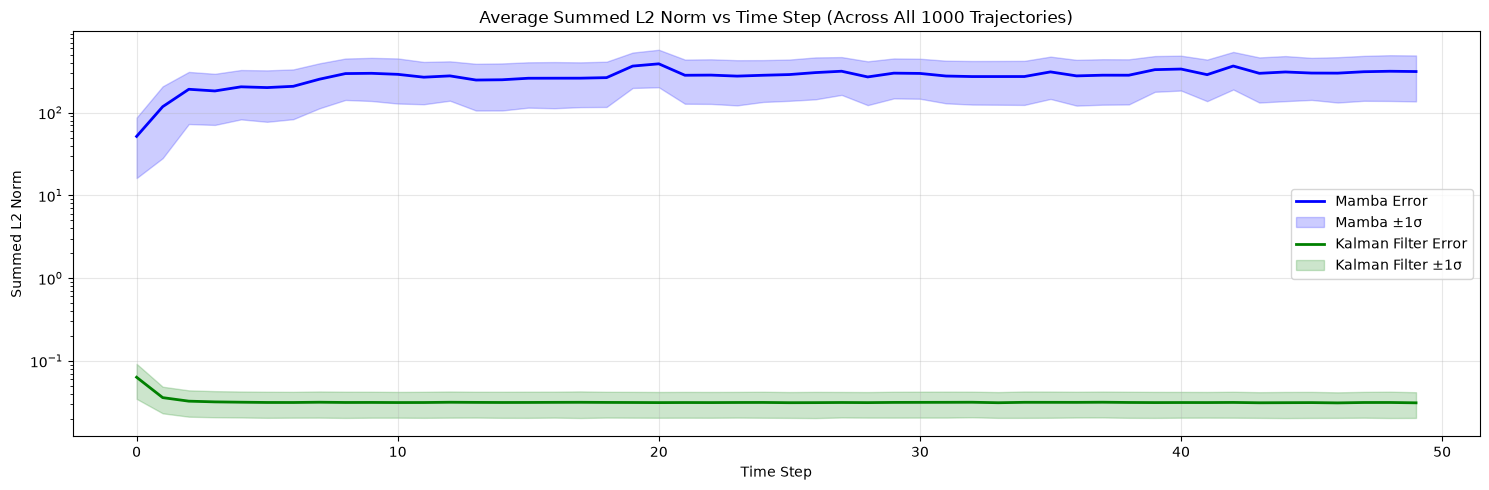

In [52]:
# 9. Example: Generate and Test Multiple Trajectories
num_trajs = 10000
print(f"\nGenerating {num_trajs} test trajectories for visualization...")
test_trajs = [
    generate_trajectory(
        nx=CONFIG['nx'],
        ny=CONFIG['ny'],
        traj_len=CONFIG['traj_len'],
        sigma_w=CONFIG['sigma_w_test'],
        sigma_v=CONFIG['sigma_v_test'],
        input_lower=CONFIG['input_lower_test'],
        input_upper=CONFIG['input_upper_test'],
        eig_low=CONFIG['eig_low_test'],
        eig_high=CONFIG['eig_high_test'],
        A = A,
        B = B,
        C = C
    )
    for _ in tqdm(range(num_trajs))
]

# Randomly sample 4 trajectory/state combinations for the trajectory plot
sampled_indices = rng.choice(len(test_trajs), size=4, replace=False)

# Store data for trajectory plot
plot_data = []
all_l2_norms = []

for idx, traj_idx in enumerate(sampled_indices):
    test_traj = test_trajs[traj_idx]
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for model
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get model predictions
    trained_model = trained_model.to(device)
    trained_model.eval()
    with torch.no_grad():
        preds_tensor = trained_model(xs_tensor)

    preds = preds_tensor.squeeze(0).cpu().numpy()

    # Compute per-time-step L2 norm
    actual_pred_len = preds.shape[0]
    actual_state_len = min(actual_pred_len, states_true[:-1].shape[0])

    # Randomly select a state dimension to plot
    nx = CONFIG['nx']
    state_dim = rng.integers(0, nx)

    # Get Kalman filter predictions
    kf_states = apply_kalman_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]  # KF state estimates

    # Store data for trajectory plot
    plot_data.append({
        'states_true': states_true[1:, state_dim],
        'preds': preds[:, state_dim],
        'kf_preds': kf_preds[:, state_dim],
        # 'obs': obs[:-1, state_dim],
        'state_dim': state_dim,
        'traj_idx': traj_idx
    })

    # Compute summed L2 norm for this trajectory
    mse = np.mean((states_true[1:][:actual_state_len] - preds[:actual_state_len]) ** 2)
    all_l2_norms.append(mse)

# Create Figure 1: Trajectory comparison plot (4 separate subplots)
plt.figure(figsize=(15, 10))
for idx, data in enumerate(plot_data):
    plt.subplot(2, 2, idx+1)
    plt.plot(data['states_true'], label='True State', linewidth=2)
    plt.plot(data['preds'], '--', label='Mamba', linewidth=2)
    plt.plot(data['kf_preds'], ':', label='Kalman Filter', linewidth=2)
    # plt.plot(data['obs'], ':', label='Observation', alpha=0.5, linewidth=1.5)
    plt.xlabel('Time Step')
    plt.ylabel(f'State Dim {data["state_dim"]}')
    plt.title(f'System {data["traj_idx"]}, State {data["state_dim"]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.suptitle('True States vs Predicted States vs Noisy Observations (Random Sample)', y=1.02)
plt.tight_layout()
# plt.savefig('results_traj.png')
# print("Trajectory plot saved to results_traj.png")


# Compute per-timestep summed L2 norm across ALL 1000 trajectories
print(f"\nComputing per-timestep summed L2 norm across all {num_trajs} trajectories...")
all_per_timestep_l2_norms = []
all_kf_per_timestep_l2_norms = []

for test_traj in tqdm(test_trajs):
    states_true = test_traj['states']
    inputs = test_traj['inputs']

    # Get model predictions
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    trained_model = trained_model.to(device)
    trained_model.eval()
    with torch.no_grad():
        preds_tensor = trained_model(xs_tensor)

    preds = preds_tensor.squeeze(0).cpu().numpy()
    actual_pred_len = preds.shape[0]
    actual_state_len = min(actual_pred_len, states_true[:-1].shape[0])

    # Get Kalman filter predictions
    kf_states = apply_kalman_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]  # KF state estimates
    kf_pred_len = min(kf_preds.shape[0], states_true[:-1].shape[0])

    # Compute per-timestep L2 norm across all state dimensions for this trajectory
    per_timestep_err = np.linalg.norm((states_true[1:][:actual_state_len] - preds[:actual_state_len]), axis=-1)
    all_per_timestep_l2_norms.append(per_timestep_err)

    # Compute per-timestep L2 norm for Kalman filter
    kf_per_timestep_err = np.linalg.norm((states_true[1:][:kf_pred_len] - kf_preds[:kf_pred_len]), axis=-1)
    all_kf_per_timestep_l2_norms.append(kf_per_timestep_err)

# Compute average and std per-timestep error across all trajectories
min_length = min(len(err_curve) for err_curve in all_per_timestep_l2_norms)
trimmed_errs = [err_curve[:min_length] for err_curve in all_per_timestep_l2_norms]
avg_per_timestep_err = np.mean(trimmed_errs, axis=0)
std_per_timestep_err = np.std(trimmed_errs, axis=0)

# Compute average and std per-timestep error for Kalman filter
kf_min_length = min(len(err_curve) for err_curve in all_kf_per_timestep_l2_norms)
trimmed_kf_errs = [err_curve[:kf_min_length] for err_curve in all_kf_per_timestep_l2_norms]
avg_kf_per_timestep_err = np.mean(trimmed_kf_errs, axis=0)
std_kf_per_timestep_err = np.std(trimmed_kf_errs, axis=0)

# Compute overall average error across all trajectories (matching plot_errs: mean of sum across time)
traj_errs_sum = np.array([err_curve.sum() for err_curve in all_per_timestep_l2_norms])
avg_err_all = traj_errs_sum.mean()

kf_traj_errs_sum = np.array([err_curve.sum() for err_curve in all_kf_per_timestep_l2_norms])
avg_kf_err_all = kf_traj_errs_sum.mean()

# Create Figure 2: Error vs time step plot - single averaged curve with error band
plt.figure(figsize=(15, 5))
plt.semilogy(avg_per_timestep_err, label='Mamba Error', linewidth=2, color='blue')
plt.fill_between(
    range(min_length),
    avg_per_timestep_err - std_per_timestep_err,
    avg_per_timestep_err + std_per_timestep_err,
    color='blue',
    alpha=0.2,
    label='Mamba ±1σ'
)
plt.semilogy(avg_kf_per_timestep_err, label='Kalman Filter Error', linewidth=2, color='green')
plt.fill_between(
    range(kf_min_length),
    avg_kf_per_timestep_err - std_kf_per_timestep_err,
    avg_kf_per_timestep_err + std_kf_per_timestep_err,
    color='green',
    alpha=0.2,
    label='Kalman Filter ±1σ'
)
plt.xlabel('Time Step')
plt.ylabel('Summed L2 Norm')
plt.title('Average Summed L2 Norm vs Time Step (Across All 1000 Trajectories)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results_l2_vs_time_mamba.png')
# print("Summed L2 Norm vs Time plot saved to results_l2_vs_time_mamba.png")
# plt.close()

print(f"\nAverage Summed L2 Error (Mamba) across ALL {num_trajs} trajectories: {avg_err_all:.3f}")
print(f"Average Summed L2 Error (Kalman Filter) across ALL {num_trajs} trajectories: {avg_kf_err_all:.3f}")


Finding best and worst state-trajectory pairs across 10000 trajectories...


100%|██████████| 10000/10000 [01:07<00:00, 148.99it/s]



Best 2 pairs:
  Traj 1620, State 2, Summed L2 Norm = 5.7865
  Traj 4999, State 2, Summed L2 Norm = 5.8540
Worst 2 pairs:
  Traj 9903, State 5, Summed L2 Norm = 115364.5625
  Traj 8694, State 5, Summed L2 Norm = 101680.4297


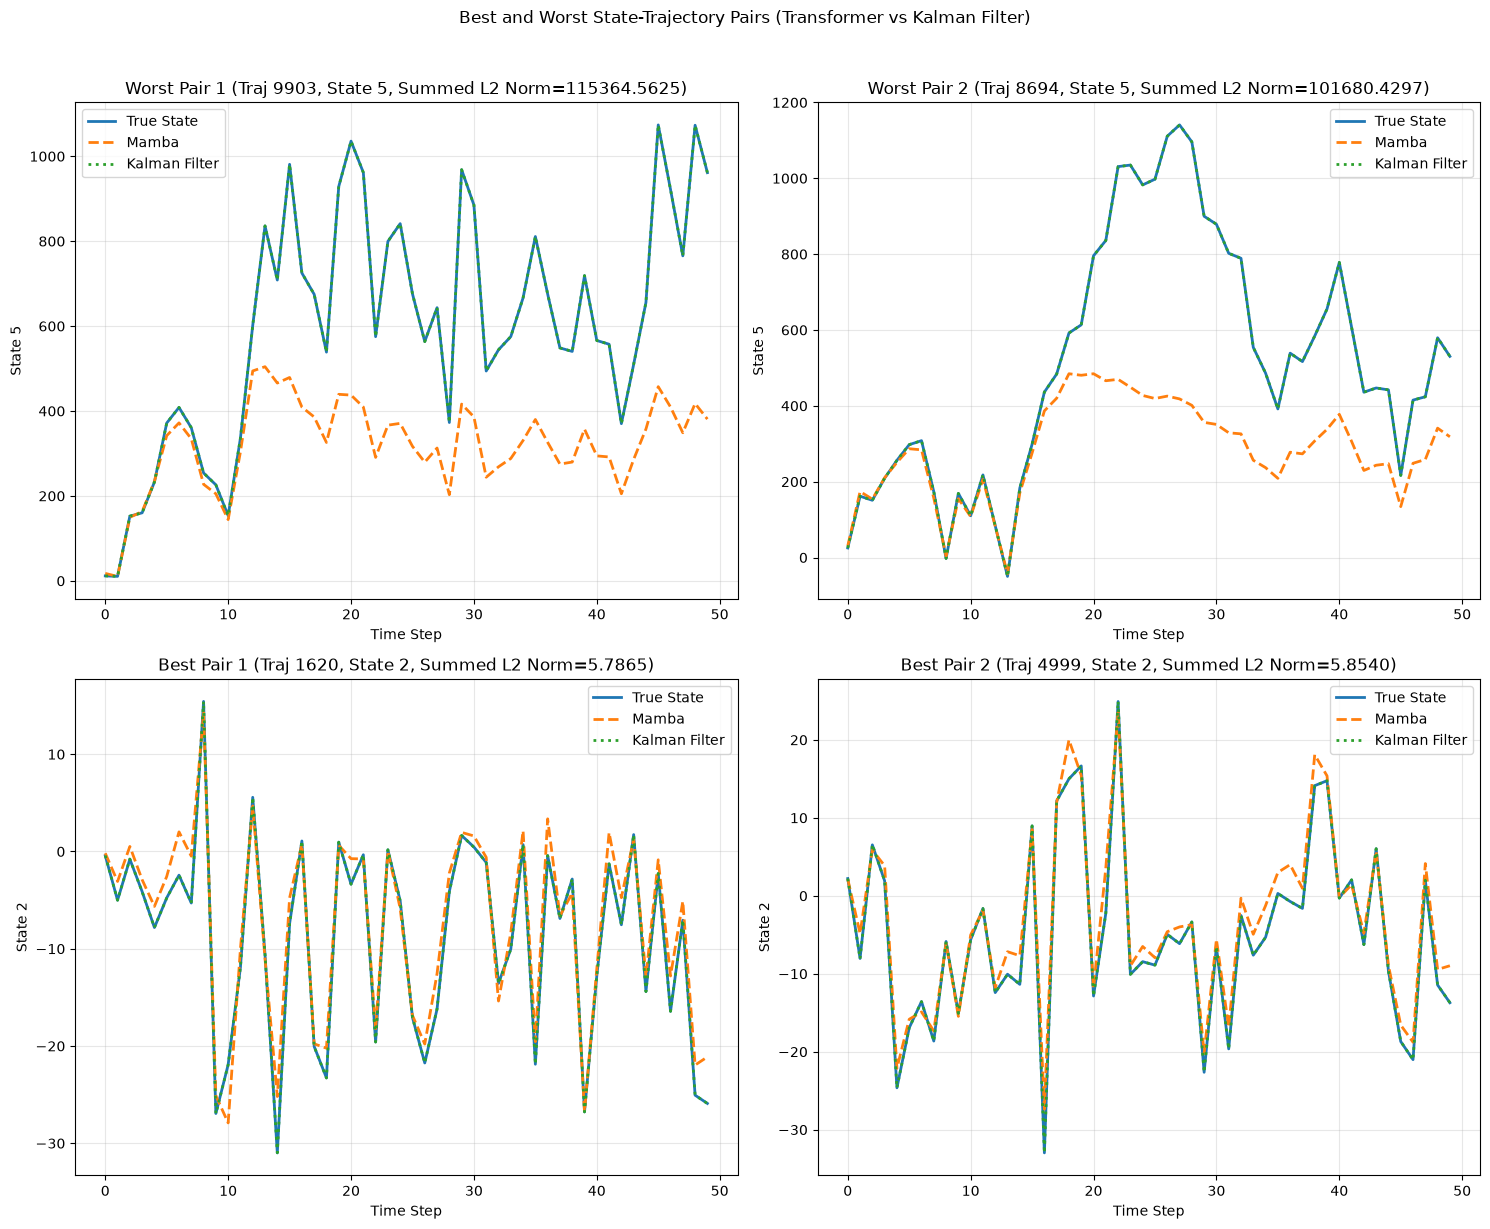

In [54]:
# Find 2 best and 2 worst-performing state-trajectory pairs across ALL test trajectories
print(f'\nFinding best and worst state-trajectory pairs across {num_trajs} trajectories...')

# Initialize storage for best and worst pairs
best_pairs = []  # List of (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len)
worst_pairs = []  # List of (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len)

for traj_idx, test_traj in enumerate(tqdm(test_trajs)):
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']
    
    # Prepare input for model
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)
    
    # Get model predictions
    trained_model = trained_model.to(device)
    trained_model.eval()
    with torch.no_grad():
        preds_tensor = trained_model(xs_tensor)
    preds = preds_tensor.squeeze(0).cpu().numpy()
    
    # Get Kalman filter predictions
    kf_states = apply_kalman_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]  # KF state estimates
    
    actual_state_len = min(preds.shape[0], states_true[:-1].shape[0], kf_preds.shape[0])
    
    for state_dim in range(CONFIG['nx']):
        # Compute summed L2 norm for this (trajectory, state_dim) pair
        pair_mse = np.mean((states_true[1:][:actual_state_len, state_dim] - 
                               preds[:actual_state_len, state_dim]) ** 2)
        
        pair_data = (pair_mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_state_len)
        
        # Add to best pairs (keep only top 2 lowest summed L2 norm)
        best_pairs.append(pair_data)
        best_pairs.sort(key=lambda x: x[0])  # Sort by summed L2 norm ascending
        if len(best_pairs) > 2:
            best_pairs.pop()  # Remove worst of the best
        
        # Add to worst pairs (keep only top 2 highest summed L2 norm)
        worst_pairs.append(pair_data)
        worst_pairs.sort(key=lambda x: x[0], reverse=True)  # Sort by summed L2 norm descending
        if len(worst_pairs) > 2:
            worst_pairs.pop()  # Remove best of the worst

# Print results
print(f'\nBest 2 pairs:')
for mse, traj_idx, state_dim, _, _, _, _ in best_pairs:
    print(f'  Traj {traj_idx}, State {state_dim}, Summed L2 Norm = {mse:.4f}')

print(f'Worst 2 pairs:')
for mse, traj_idx, state_dim, _, _, _, _ in worst_pairs:
    print(f'  Traj {traj_idx}, State {state_dim}, Summed L2 Norm = {mse:.4f}')

# Create 2x2 plot: [worst1, worst2, best1, best2]
plt.figure(figsize=(15, 12))

# Combine all pairs: worst first, then best
all_pairs_to_plot = worst_pairs + best_pairs
titles = ['Worst Pair 1', 'Worst Pair 2', 'Best Pair 1', 'Best Pair 2']

for idx, (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len) in enumerate(all_pairs_to_plot):
    plt.subplot(2, 2, idx + 1)
    plt.plot(states_true[1:, state_dim], label='True State', linewidth=2)
    plt.plot(preds[:actual_len, state_dim], '--', label='Mamba', linewidth=2)
    plt.plot(kf_preds[:actual_len, state_dim], ':', label='Kalman Filter', linewidth=2)
    plt.xlabel('Time Step')
    plt.ylabel(f'State {state_dim}')
    plt.title(f'{titles[idx]} (Traj {traj_idx}, State {state_dim}, Summed L2 Norm={mse:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Best and Worst State-Trajectory Pairs (Transformer vs Kalman Filter)', y=1.02)
plt.tight_layout()
plt.show()
